In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
data=pd.read_csv("/kaggle/input/titanic/train.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
data1=pd.read_csv("/kaggle/input/titanic/test.csv")
data1

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
data1.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
data1.drop(['Cabin','Name'],axis=1, inplace=True)
data1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,male,34.5,0,0,330911,7.8292,Q
1,893,3,female,47.0,1,0,363272,7.0000,S
2,894,2,male,62.0,0,0,240276,9.6875,Q
3,895,3,male,27.0,0,0,315154,8.6625,S
4,896,3,female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...
413,1305,3,male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,female,39.0,0,0,PC 17758,108.9000,C
415,1307,3,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,male,NaN,0,0,359309,8.0500,S


In [7]:
data.drop(['Cabin','Name'],axis=1, inplace=True)
data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,female,35.0,1,0,113803,53.1000,S
4,5,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,S
887,888,1,1,female,19.0,0,0,112053,30.0000,S
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,male,26.0,0,0,111369,30.0000,C


In [8]:
data1['Age'] = data1['Age'].fillna(data1['Age'].mode()[0])
data1['Fare'] = data1['Fare'].fillna(data1['Fare'].mean())
data1.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,male,34.5,0,0,330911,7.8292,Q
1,893,3,female,47.0,1,0,363272,7.0000,S
2,894,2,male,62.0,0,0,240276,9.6875,Q
3,895,3,male,27.0,0,0,315154,8.6625,S
4,896,3,female,22.0,1,1,3101298,12.2875,S


In [9]:
data['Age'] = data['Age'].fillna(data['Age'].mode()[0])
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,female,35.0,1,0,113803,53.1000,S
4,5,0,3,male,35.0,0,0,373450,8.0500,S


In [10]:

data1.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [11]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [12]:
df6=pd.get_dummies(data1['Sex'])
df6

,female,male
0,0,1
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
413,0,1
414,1,0
415,0,1
416,0,1


In [13]:
df=pd.get_dummies(data['Sex'])
df

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


In [14]:
data1=data1.drop(labels=['Sex','Ticket'], axis=1 )
data1

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Embarked
0,892,3,34.5,0,0,7.8292,Q
1,893,3,47.0,1,0,7.0000,S
2,894,2,62.0,0,0,9.6875,Q
3,895,3,27.0,0,0,8.6625,S
4,896,3,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
413,1305,3,21.0,0,0,8.0500,S
414,1306,1,39.0,0,0,108.9000,C
415,1307,3,38.5,0,0,7.2500,S
416,1308,3,21.0,0,0,8.0500,S


In [15]:
data=data.drop(labels=['Sex','Ticket'], axis=1 )
data


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,22.0,1,0,7.2500,S
1,2,1,1,38.0,1,0,71.2833,C
2,3,1,3,26.0,0,0,7.9250,S
3,4,1,1,35.0,1,0,53.1000,S
4,5,0,3,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,S
887,888,1,1,19.0,0,0,30.0000,S
888,889,0,3,24.0,1,2,23.4500,S
889,890,1,1,26.0,0,0,30.0000,C


In [16]:
horizontal_concat1 = pd.concat([data1, df6], axis=1)
horizontal_concat1

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Embarked,female,male
0,892,3,34.5,0,0,7.8292,Q,0,1
1,893,3,47.0,1,0,7.0000,S,1,0
2,894,2,62.0,0,0,9.6875,Q,0,1
3,895,3,27.0,0,0,8.6625,S,0,1
4,896,3,22.0,1,1,12.2875,S,1,0
...,...,...,...,...,...,...,...,...,...
413,1305,3,21.0,0,0,8.0500,S,0,1
414,1306,1,39.0,0,0,108.9000,C,1,0
415,1307,3,38.5,0,0,7.2500,S,0,1
416,1308,3,21.0,0,0,8.0500,S,0,1


In [17]:
horizontal_concat = pd.concat([data, df], axis=1)
horizontal_concat

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,female,male
0,1,0,3,22.0,1,0,7.2500,S,0,1
1,2,1,1,38.0,1,0,71.2833,C,1,0
2,3,1,3,26.0,0,0,7.9250,S,1,0
3,4,1,1,35.0,1,0,53.1000,S,1,0
4,5,0,3,35.0,0,0,8.0500,S,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,S,0,1
887,888,1,1,19.0,0,0,30.0000,S,1,0
888,889,0,3,24.0,1,2,23.4500,S,1,0
889,890,1,1,26.0,0,0,30.0000,C,0,1


In [18]:
df7=horizontal_concat1.dropna(axis=0)
df7.head()
df7.shape

(418, 9)

In [19]:
df1=horizontal_concat.dropna(axis=0)
df1.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,female,male
0,1,0,3,22.0,1,0,7.2500,S,0,1
1,2,1,1,38.0,1,0,71.2833,C,1,0
2,3,1,3,26.0,0,0,7.9250,S,1,0
3,4,1,1,35.0,1,0,53.1000,S,1,0
4,5,0,3,35.0,0,0,8.0500,S,0,1


In [20]:
df1.shape

(889, 10)

In [21]:
df8=df7.drop('Embarked',axis=1)


In [22]:
df2 = df1[['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'female', 'male']]

In [23]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df8['embarked']=le1.fit(df7['Embarked']).transform(df7['Embarked'])
df8.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,female,male,embarked
0,892,3,34.5,0,0,7.8292,0,1,1
1,893,3,47.0,1,0,7.0000,1,0,2
2,894,2,62.0,0,0,9.6875,0,1,1
3,895,3,27.0,0,0,8.6625,0,1,2
4,896,3,22.0,1,1,12.2875,1,0,2


In [24]:
x_test=df8

pt=data1['PassengerId']
pt

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [25]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df2['embarked']=le.fit(df1['Embarked']).transform(df1['Embarked'])
df2.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,embarked
0,1,0,3,22.0,1,0,7.2500,0,1,2
1,2,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,3,26.0,0,0,7.9250,1,0,2
3,4,1,1,35.0,1,0,53.1000,1,0,2
4,5,0,3,35.0,0,0,8.0500,0,1,2


<AxesSubplot:title={'center':'Heatmap displaying the correlations between all columns'}>

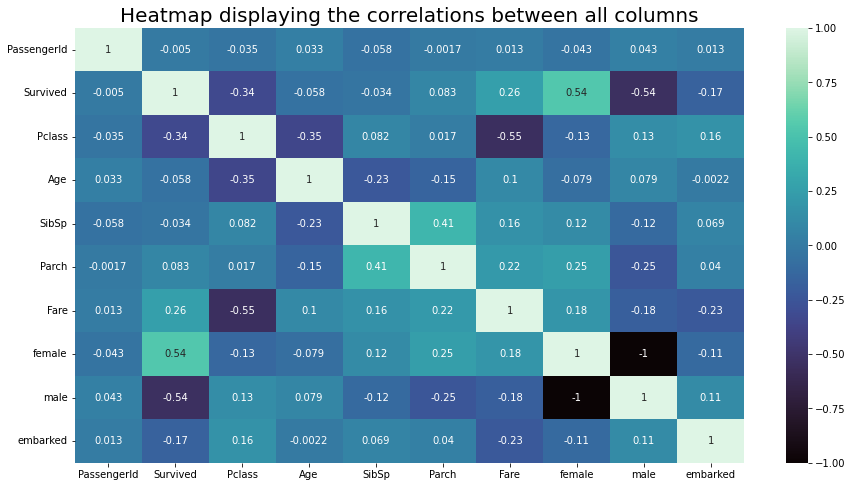

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (15,8))
plt.title("Heatmap displaying the correlations between all columns", fontsize = 20)
sns.heatmap(df2.corr(), annot=True, cmap="mako")

In [27]:
df3=df2.drop('Survived',axis=1)
y=df2['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64

In [28]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled1=sc.fit(df8).transform(df8)
df_scaled1 = pd.DataFrame(scaled1, columns=df8.columns)
df_scaled1.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,female,male,embarked
0,-1.727912,0.873482,0.466044,-0.499470,-0.400248,-0.498407,-0.755929,0.755929,-0.470915
1,-1.719625,0.873482,1.415579,0.616992,-0.400248,-0.513274,1.322876,-1.322876,0.700767
2,-1.711337,-0.315819,2.555021,-0.499470,-0.400248,-0.465088,-0.755929,0.755929,-0.470915
3,-1.703050,0.873482,-0.103676,-0.499470,-0.400248,-0.483466,-0.755929,0.755929,0.700767
4,-1.694763,0.873482,-0.483490,0.616992,0.619896,-0.418471,1.322876,-1.322876,0.700767


In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled=sc.fit(df3).transform(df3)
df_scaled = pd.DataFrame(scaled, columns=df3.columns)
df_scaled.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,female,male,embarked
0,-1.732505,0.825209,-0.495519,0.431350,-0.474326,-0.500240,-0.735342,0.735342,0.586840
1,-1.728611,-1.572211,0.720711,0.431350,-0.474326,0.788947,1.359911,-1.359911,-1.939555
2,-1.724718,0.825209,-0.191461,-0.475199,-0.474326,-0.486650,1.359911,-1.359911,0.586840
3,-1.720825,-1.572211,0.492668,0.431350,-0.474326,0.422861,1.359911,-1.359911,0.586840
4,-1.716931,0.825209,0.492668,-0.475199,-0.474326,-0.484133,-0.735342,0.735342,0.586840


In [30]:
x=df_scaled
x

,PassengerId,Pclass,Age,SibSp,Parch,Fare,female,male,embarked
0,-1.732505,0.825209,-0.495519,0.431350,-0.474326,-0.500240,-0.735342,0.735342,0.586840
1,-1.728611,-1.572211,0.720711,0.431350,-0.474326,0.788947,1.359911,-1.359911,-1.939555
2,-1.724718,0.825209,-0.191461,-0.475199,-0.474326,-0.486650,1.359911,-1.359911,0.586840
3,-1.720825,-1.572211,0.492668,0.431350,-0.474326,0.422861,1.359911,-1.359911,0.586840
4,-1.716931,0.825209,0.492668,-0.475199,-0.474326,-0.484133,-0.735342,0.735342,0.586840
...,...,...,...,...,...,...,...,...,...
884,1.716931,-0.373501,-0.115447,-0.475199,-0.474326,-0.384475,-0.735342,0.735342,0.586840
885,1.720825,-1.572211,-0.723562,-0.475199,-0.474326,-0.042213,1.359911,-1.359911,0.586840
886,1.724718,0.825209,-0.343490,0.431350,2.006119,-0.174084,1.359911,-1.359911,0.586840
887,1.728611,-1.572211,-0.191461,-0.475199,-0.474326,-0.042213,-0.735342,0.735342,-1.939555


In [31]:
from sklearn.svm import SVC
clf=SVC(kernel='linear',random_state=51)
model=clf.fit(x,y)
y_pred1=model.predict(x_test)
y_pred1
x_test.shape

(418, 9)

In [32]:
from sklearn.metrics import accuracy_score
#print(accuracy_score(y_test,y_pred1))

In [33]:
from sklearn.linear_model import LogisticRegression
clf1=LogisticRegression()
model=clf1.fit(x,y)
y_pred=model.predict(x_test)
y_pred
from sklearn.metrics import accuracy_score
#print(accuracy_score(y_test,y_pred))

In [34]:
from sklearn.neighbors import KNeighborsClassifier 
clf2=KNeighborsClassifier()
model=clf2.fit(x,y)
y_pred=model.predict(x_test)
y_pred
from sklearn.metrics import accuracy_score
#print(accuracy_score(y_test,y_pred))

In [35]:
data4=pd.DataFrame([pt,y_pred1])
data4


,0,1,2,3,4,5,6,7,8,9,...,408,409,410,411,412,413,414,415,416,417
PassengerId,892,893,894,895,896,897,898,899,900,901,...,1300,1301,1302,1303,1304,1305,1306,1307,1308,1309
Unnamed 0,0,1,0,0,1,0,1,0,1,0,...,1,1,1,1,1,0,1,0,0,0


In [36]:
k = pd.DataFrame(y_pred1,columns=['Survived'])
result = pd.concat([pt,k],axis=1)
result

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [37]:
result.to_csv('submission.csv', index=False)